# Introduction

In Part 1 of this assessment, you will complete several requested SQL queries to extract data, analyze, and provide insights from a single provided SQL database. You will also visualize the key results of three of these queries. Several "Reflection" questions ask you to write out a text-based answer in the provided markdown cell.

In Part 2, you will explore a second dataset on your own using SQL to conduct a preliminary analysis. You will be asked to produce a very short slide presentation highlighting the work you did for this second section.

## Objectives
You will be able to:
- Interpret "word problems" and translate them into SQL queries.
- Decide and use whichever JOIN type is best for retrieving the desired data.
- Use GROUP BY statements to apply aggregate functions like COUNT, MAX, MIN, and SUM.
- Use the HAVING clause to compare different aggregates.
- Write subqueries to decompose complex queries.
- Visualize data using Matplotlib, Seaborn, or Pandas.
- Choose the correct chart type based on the given data.

## Part 1: Guided SQL Queries

### Your Task: Querying a Customer Database

![toy car picture](images/toycars.jpg)


### Business Understanding
Your employer sells wholesale miniature models of products such as classic cars, motorcycles, and planes. They want you to pull several reports on different segments of their past customers to understand past sales better and determine which customers will receive promotional materials. They are also interested in investigating which products have performed best, as well as in making several smaller asks.

In addition to providing the requested data from the SQL database, you have also been asked to create basic visuals to display more insightful information. It is up to your discretion to choose the correct plot/chart type for the data in question. Questions that want you to visualize the results will be explicitly marked.

### Data Understanding
You may remember this database from a previous lab. As a refresher, here's the ERD diagram for this database:

![ERD picture](images/ERD.png)

### Getting Started
For this assessment, you are expected to make use of both SQLite3 and the Pandas library to write, execute, and return SQL queries as a Pandas DataFrame. Assign each returned answer as its own explicit variable. The queries you are asked to write will become more complex over the course of the lab.

For the visualization piece, you are expected to utilize either Pandas, Seaborn, or Matplotlib to create your visuals. Make sure you provide clear labels and titles for the data you are being asked to visualize. Do not worry too much about choosing a "style" or "context"; instead, focus on conveying the requested information correctly.

### Step 1: Connect to Data

In the cell below:
- Import the necessary libraries.
- Establish a connection to the database "data.sqlite."

In [1]:
import sqlite3
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

conn = sqlite3.connect("data.sqlite")

### Step 2: Limited Edition California Product
The California sales rep team is interested in distributing promotional materials for a new limited-edition model they are releasing based on the famous San Francisco Cable Cars. This product will only be available to customer stores based in California, and given its high price, they want to first target promotional materials to existing California customers with high credit limits. After speaking with the accounting department, a credit limit of over 25,000 is considered high.

Execute a SQL query that returns which customers the sales rep team wants to market to first.

*Hint: Make sure creditLimit is numeric.*

In [2]:
q = """
       SELECT customerNumber, customerName, city, state, CAST(creditLimit AS
              REAL) AS creditLimitNumeric
         FROM customers
        WHERE state = "CA" AND creditLimitNumeric > 25000;
    """

high_credit_limit_customers_df = pd.read_sql(q, conn)
high_credit_limit_customers_df

,customerNumber,customerName,city,state,creditLimitNumeric
0,124,Mini Gifts Distributors Ltd.,San Rafael,CA,210500.0
1,129,Mini Wheels Co.,San Francisco,CA,64600.0
2,161,Technics Stores Inc.,Burlingame,CA,84600.0
3,205,Toys4GrownUps.com,Pasadena,CA,90700.0
4,239,Collectable Mini Designs Co.,San Diego,CA,105000.0
5,321,Corporate Gift Ideas Co.,San Francisco,CA,105000.0
6,347,"Men 'R' US Retailers, Ltd.",Los Angeles,CA,57700.0
7,450,The Sharp Gifts Warehouse,San Jose,CA,77600.0
8,475,West Coast Collectables Co.,Burbank,CA,55400.0
9,487,Signal Collectibles Ltd.,Brisbane,CA,60300.0


### Step 3: International Collectable Campaign

The international sales rep team has reached out to you to help them identify partners for a "Collectable" marketing campaign that highlights the value collectors see in purchasing these model kits. They want to try to promote a "collect them all" mentality. The team had a great idea to partner with any of their international customers (non-US) who have "Collect" in their name as a tie-in to the larger theme.

Execute a SQL query that returns the customers in question.

In [3]:
q = """
       SELECT customerNumber, customerName, city, country
         FROM customers
        WHERE country != "USA" AND customerName LIKE "%collect%"
    """

collectable_campaign_customers_df = pd.read_sql(q, conn)
collectable_campaign_customers_df

,customerNumber,customerName,city,country
0,114,"Australian Collectors, Co.",Melbourne,Australia
1,189,"Clover Collections, Co.",Dublin,Ireland
2,201,"UK Collectables, Ltd.",Liverpool,UK
3,211,"King Kong Collectables, Co.",Central Hong Kong,Hong Kong
4,227,Heintze Collectables,Århus,Denmark
5,260,"Royal Canadian Collectables, Ltd.",Tsawassen,Canada
6,293,BG&E Collectables,Fribourg,Switzerland
7,353,Reims Collectables,Reims,France
8,376,Precious Collectables,Bern,Switzerland
9,382,Salzburg Collectables,Salzburg,Austria


## Reflection Question:

#### Describe the WHERE clause you used in the above query to a non-technical manager who wants to ensure that you are properly filtering and only selecting the requested data. How is the operator and conditional expression you are using acting to accomplish this?

The WHERE clause used in the above query first filters the results by ensuring that the country associated with the customer is not equal to (which SQL represents as "!=") the text "USA." Only customers with a country outside the USA will be included in the results. Then, using the "LIKE" keyword, it filters all customer names to look only for names that include "collect" somewhere in the name. The % wildcard means that any text of any length can appear in the name before or after "collect," but "collect" must appear in the customer name somewhere. The AND conditional operator is used to ensure that BOTH required conditions (non-US AND have "collect" somewhere in their name) are met in order to include a given customer record in the result table.

### Step 4: USA Credit and Inventory Policy - Visual Required
The USA-based product team is planning to adjust its credit policies and inventory allocation strategy based on the average credit limit of its customers. They would like to target this strategy at a state level with several goals in mind. 
1. Optimize inventory distribution:
    - States with higher average credit limits could place larger orders, justifying priority in inventory allocation.
    - This could help ensure that states with more purchasing power always have products in stock.
2. Tailor credit policies:
    - Adjust credit limits for new customers based on the state average.
    - Identify states where they might be too conservative or too liberal with credit limits.
3. Target marketing and sales efforts:
    - Focus promotional campaigns on states with higher credit limits to lead to larger orders.
    - Develop strategies to increase sales in states with lower average credit limits.

Execute a SQL query that returns the information required to address this ask.

In [4]:
#We need to write a SQL query that tells us the average credit limit of
#customers grouped by state. In order to see which states have the highest
#average credit limits, we need to sort the results by highest credit limit in
#descending order, so that the highest limits will be at the top.
q = """
         SELECT state, ROUND(AVG(CAST(creditLimit AS REAL)), 2) AS
                averageCreditLimit
           FROM customers
          WHERE country = "USA"
       GROUP BY state
       ORDER BY averageCreditLimit DESC;
    """

state_avg_credit_limit_df = pd.read_sql(q, conn)
state_avg_credit_limit_df

,state,averageCreditLimit
0,NH,114200.00
1,NY,89966.67
2,PA,84766.67
3,CA,83854.55
4,NV,71800.00
5,MA,70755.56
6,CT,57350.00
7,NJ,43000.00


Once you have the information returned in a DataFrame, select an appropriate visualization to represent this data. You are welcome to utilize Matplotlib, Seaborn, or Pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

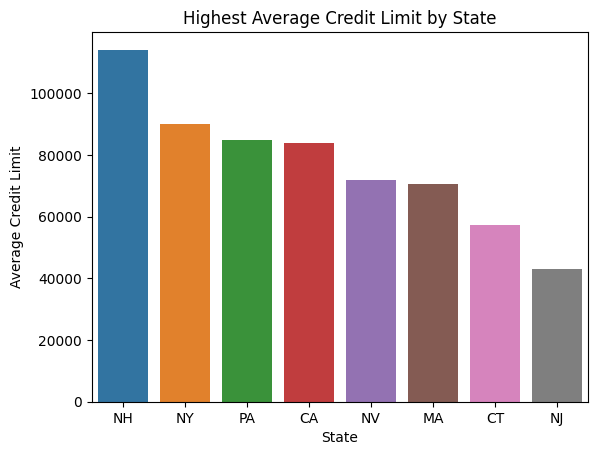

In [5]:
sns.barplot(data = state_avg_credit_limit_df, x = "state", y = 
            "averageCreditLimit", hue = "state")
plt.xlabel("State")
plt.ylabel("Average Credit Limit")
plt.title("Highest Average Credit Limit by State")
plt.show()

### Step 5: Top Customers - Visual Required
The company is approaching its 10th anniversary and wants to acknowledge and thank its top customers with personalized communication. They have asked you to determine the top 10 customers by total payment amount, and to return the customer name for clarity.

Execute a SQL query that returns the information required to address this ask.

In [6]:
q = """
         SELECT c.customerNumber, c.customerName, SUM(p.amount) AS
                totalAmountPaid
           FROM customers AS c
           JOIN payments AS p
                USING (customerNumber)
       GROUP BY c.customerNumber
       ORDER BY totalAmountPaid DESC
          LIMIT 10;
    """

top_10_paying_customers_df = pd.read_sql(q, conn)
top_10_paying_customers_df

,customerNumber,customerName,totalAmountPaid
0,141,Euro+ Shopping Channel,715738.98
1,124,Mini Gifts Distributors Ltd.,584188.24
2,114,"Australian Collectors, Co.",180585.07
3,151,Muscle Machine Inc,177913.95
4,148,"Dragon Souveniers, Ltd.",156251.03
5,323,"Down Under Souveniers, Inc",154622.08
6,187,"AV Stores, Co.",148410.09
7,276,"Anna's Decorations, Ltd",137034.22
8,321,Corporate Gift Ideas Co.,132340.78
9,146,"Saveley & Henriot, Co.",130305.35


Once you have the information returned in a DataFrame, select an appropriate visualization to represent this data. You are welcome to utilize Matplotlib, Seaborn, or Pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

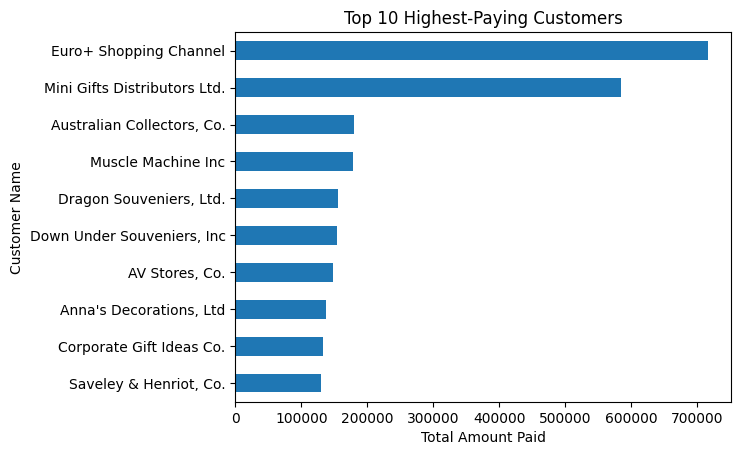

In [7]:
ax = top_10_paying_customers_df.plot(kind = "barh", x = "customerName", y =
                                     "totalAmountPaid", xlabel = "Total Amount Paid", ylabel = "Customer Name", title = "Top 10 Highest-Paying Customers", legend = False)
#Horizontal bar graphs are built bottom to top by Pandas, but my df has the
#highest-paying customer at the top. To make the graph align with this and have
#the highest-paying customer at the top, we invert the y-axis:
ax.invert_yaxis()
plt.show()

### Step 6: Top Customer + Product Quantities
The product team is analyzing the most popular products sold to each customer to determine which new products to include in their catalog. Individual sales reps will also use this data to recommend similar products to each customer when they place an order next time.

They have asked you to query information for each customer about any product they have purchased in 10 or more units. In addition, they would like the full set of data to be sorted in ascending order by the total amount purchased.

Execute a SQL query that returns the information required to address this ask.

*Hint: For this one, you'll need to make use of HAVING, GROUP BY, and ORDER BY — make sure you get the order of them correct!*

In [8]:
q = """
         SELECT c.customerNumber, c.customerName, od.productCode,
                p.productName, SUM(od.quantityOrdered) AS totalQuantityPurchased
           FROM customers AS c
           JOIN orders AS o
                USING (customerNumber)
           JOIN orderdetails AS od
                USING (orderNumber)
           JOIN products AS p
                USING (productCode)
       GROUP BY c.customerNumber, od.productCode
         HAVING SUM(od.quantityOrdered) >= 10
       ORDER BY totalQuantityPurchased ASC;
    """

most_popular_products_by_customer_df = pd.read_sql(q, conn)
most_popular_products_by_customer_df

,customerNumber,customerName,productCode,productName,totalQuantityPurchased
0,314,Petit Auto,S18_2949,1913 Ford Model T Speedster,10
1,412,"Extreme Desk Decorations, Ltd",S24_4620,1961 Chevrolet Impala,10
2,119,La Rochelle Gifts,S32_2509,1954 Greyhound Scenicruiser,11
3,328,Tekni Collectables Inc.,S700_1691,American Airlines: B767-300,11
4,450,The Sharp Gifts Warehouse,S24_3191,1969 Chevrolet Camaro Z28,13
...,...,...,...,...,...
2526,141,Euro+ Shopping Channel,S24_3432,2002 Chevy Corvette,174
2527,141,Euro+ Shopping Channel,S12_4473,1957 Chevy Pickup,183
2528,141,Euro+ Shopping Channel,S24_1444,1970 Dodge Coronet,197
2529,141,Euro+ Shopping Channel,S24_2840,1958 Chevy Corvette Limited Edition,245


### Step 7: Product Analysis - Visual Required

The product team is looking into the demand across its different product lines. They are conducting a comprehensive review of their product portfolio and inventory management strategies. You have been asked to query data for each product line, including the total quantity ordered and the total number of products for each line. By examining the number of products and total quantity ordered for each product line, the company aims to:
1. Optimize product mix:
    - Identify which product lines have the most diverse offerings (high number of products).
    - Determine which lines are most popular (those with the highest total quantity ordered).
    - Compare if lines with more products necessarily lead to more orders.
2. Improve inventory management:
    - Adjust stock levels based on the popularity of each product line.
    - Identify potential overstocking in lines with low order quantities.
    - Ensure adequate variety in high-performing product lines.
3. Adjust marketing strategy:
    - Focus promotional efforts on high-potential product lines (many products with lower order quantities).
    - Capitalize on the popularity of high-performing lines in marketing campaigns.
4. Advise product development:
    - Invest in expanding product ranges for lines with high order quantities.
    - Consider phasing out or revamping product lines with few products and low order quantities.

*Hint: Think about how you can and might have to utilize the SQL DISTINCT statement.*

Execute a SQL query that returns the information required to address this ask.

In [9]:
#For each product line, we want the total quantity ordered and the total number
#of products that belong to that product line. I will select these columns in
#the opposite order so that we can see whether product lines with more products
#are getting ordered more. In order to make it easy to identify which product
#lines have the highest number of products, we should order our results by
#total number of products in descending order, so that the highest numbers will
#be at the top. Then, we will order by total quantity ordered in descending
#order, so that if two product lines have the same number of products, they
#will be sorted by the one with more orders. I will use a LEFT JOIN because I
#want all product lines, even if there are no orders associated with them.
q = """
         SELECT p.productLine, COUNT(DISTINCT p.productCode) AS
                totalNumberOfProducts, SUM(od.quantityOrdered) AS
                totalQuantityOrdered
           FROM products AS p
           LEFT JOIN orderdetails AS od
                USING (productCode)
       GROUP BY p.productLine
       ORDER BY totalNumberOfProducts DESC, totalQuantityOrdered DESC;
    """

product_line_quantities_and_orders_df = pd.read_sql(q, conn)
product_line_quantities_and_orders_df

,productLine,totalNumberOfProducts,totalQuantityOrdered
0,Classic Cars,38,35582
1,Vintage Cars,24,22933
2,Motorcycles,13,12778
3,Planes,12,11872
4,Trucks and Buses,11,11001
5,Ships,9,8532
6,Trains,3,2818


Once you have the information returned in a DataFrame, select an appropriate visualization to represent the relationship between total quantity ordered and the number of products to perform a preliminary investigation into the question of whether more products lead to more orders. You are welcome to utilize Matplotlib, Seaborn, or Pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

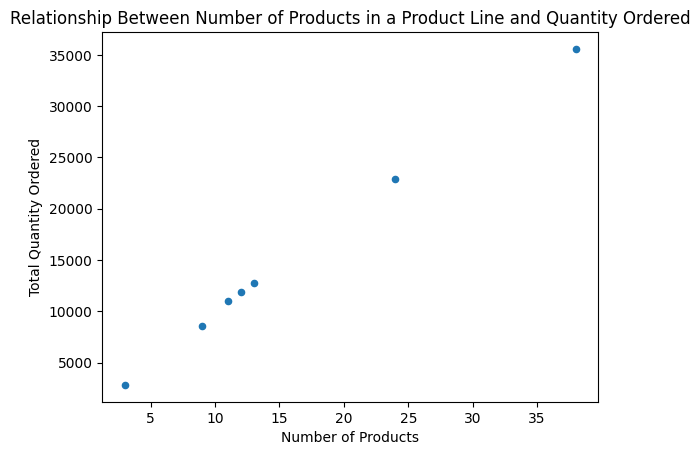

In [10]:
product_line_quantities_and_orders_df.plot(kind = "scatter", x = 
                                           "totalNumberOfProducts", y = "totalQuantityOrdered", xlabel = "Number of Products", ylabel = "Total Quantity Ordered", title = "Relationship Between Number of Products in a Product Line and Quantity Ordered")
plt.show()

## Reflection Question:

#### Please explain your choice in the visual you used to highlight and represent the data from the above query. In a non-technical manner, explain why that chart type makes sense for the information being conveyed. What does this visual convey in the context of the question it was asked for?

I used a scatter plot to represent the data above because scatter plots are good visualizations for the relationship between two numeric variables. Number of products in a product line and total quantity ordered are both numeric variables, so if we want to explore the relationship between them, a scatter plot is a good choice because it can show individual data points that show the quantity ordered based on how many products are in a product line. In the context of the question of whether more products lead to more orders, the scatter plot shows a positive relationship, which indicates that generally product lines that have a higher number of products will also have more orders associated with them. This makes sense because the more product options that there are in a particular product line, the more likely it is that there will be a product in the line that appeals to a particular customer.

### Step 8: Remote Offices
Upper management is considering a shift to hybrid and remote work for certain locations and roles. They have tasked you with providing them with data on employees in any office with fewer than 5 employees, so they can better understand how to support those employees remotely when offices are closed. 

Be sure to include information about the employee's job and supervisor so management can properly transition everyone to remote work.

*Hint: Utilize a subquery to find the relevant offices*

Execute a SQL query that returns the information required to address this ask.

In [11]:
q = """
         SELECT e.employeeNumber, e.lastName AS employeeLastName, e.firstName
                AS employeeFirstName, e.jobTitle, e.reportsTo AS supervisorNumber, s.firstName AS supervisorFirstName,
                s.lastName AS supervisorLastName, o.officeCode, o.city AS officeCity
           FROM employees AS e
           JOIN offices AS o
                USING (officeCode)
           JOIN employees AS s
                ON e.reportsTo = s.employeeNumber
          WHERE o.officeCode IN 
                (  SELECT o.officeCode
                     FROM offices AS o
                     JOIN employees AS e
                          USING (officeCode)
                 GROUP BY o.officeCode
                   HAVING COUNT(e.employeeNumber) < 5);
    """

future_hybrid_and_remote_employees_df = pd.read_sql(q, conn)
future_hybrid_and_remote_employees_df

,employeeNumber,employeeLastName,employeeFirstName,jobTitle,supervisorNumber,supervisorFirstName,supervisorLastName,officeCode,officeCity
0,1188,Firrelli,Julie,Sales Rep,1143,Anthony,Bow,2,Boston
1,1216,Patterson,Steve,Sales Rep,1143,Anthony,Bow,2,Boston
2,1286,Tseng,Foon Yue,Sales Rep,1143,Anthony,Bow,3,NYC
3,1323,Vanauf,George,Sales Rep,1143,Anthony,Bow,3,NYC
4,1621,Nishi,Mami,Sales Rep,1056,Mary,Patterson,5,Tokyo
5,1625,Kato,Yoshimi,Sales Rep,1621,Mami,Nishi,5,Tokyo
6,1088,Patterson,William,Sales Manager (APAC),1056,Mary,Patterson,6,Sydney
7,1611,Fixter,Andy,Sales Rep,1088,William,Patterson,6,Sydney
8,1612,Marsh,Peter,Sales Rep,1088,William,Patterson,6,Sydney
9,1619,King,Tom,Sales Rep,1088,William,Patterson,6,Sydney


## Reflection Question:

#### Describe how you decided on the subquery that you used in the query above. This answer can be technical, describing your thought process on how the main query is utilizing the subquery to return the correct data.

The subquery I used returns every office code (which is the primary key of the offices table) that has an employee count of fewer than five. Since employeeNumber is the primary key of the employees table, using COUNT(employeeNumber) ensures that employees will not be double-counted. This allowed me to reference the appropriate office codes in my main query because the main query was looking for information about employees in offices with fewer than five employees. My subquery returns which offices have fewer than five employees, and then my main query only returns information about employees working in those offices.

### Step 9: Close the Connection

Now that you are finished executing your queries and retrieving the required information, you always want to make sure to close the connection to your database.

In [12]:
conn.close()

### End of Guided Section
In this initial portion of the assessment, you produced several data queries and visualizations for a model company, mainly focused on its customer and product data. You wrote and engineered specific SQL queries to address pertinent questions and requests from the company. Along the way, you utilized many of the major concepts and keywords associated with SQL SELECT queries: FROM, WHERE, GROUP BY, HAVING, ORDER BY, JOIN, SUM, COUNT, and AVG.

## Part 2: Exploratory Analysis with SQL
In this open-ended exploratory section, you will analyze real-world data from the movie industry. As a data analyst, you have the freedom to investigate questions and topics that intrigue you within this dataset. The database schema and Entity-Relationship Diagram (ERD) are provided below for your reference. A general overview and instructions are also provided below.

In [13]:
#Run this cell without changes
import zipfile

zip_file_path = "im.db.zip"
extract_to_path = "./"

with zipfile.ZipFile(zip_file_path, "r") as zip_ref:
    zip_ref.extractall(extract_to_path)

#Connect to the database:
conn4 = sqlite3.connect("im.db")

#Database schema:
schema_df = pd.read_sql("""
                           SELECT *
                             FROM sqlite_master;
                        """, conn4)
schema_df

,type,name,tbl_name,rootpage,sql
0,table,movie_basics,movie_basics,2,"CREATE TABLE ""movie_basics"" (\n""movie_id"" TEXT..."
1,table,directors,directors,3,"CREATE TABLE ""directors"" (\n""movie_id"" TEXT,\n..."
2,table,known_for,known_for,4,"CREATE TABLE ""known_for"" (\n""person_id"" TEXT,\..."
3,table,movie_akas,movie_akas,5,"CREATE TABLE ""movie_akas"" (\n""movie_id"" TEXT,\..."
4,table,movie_ratings,movie_ratings,6,"CREATE TABLE ""movie_ratings"" (\n""movie_id"" TEX..."
5,table,persons,persons,7,"CREATE TABLE ""persons"" (\n""person_id"" TEXT,\n ..."
6,table,principals,principals,8,"CREATE TABLE ""principals"" (\n""movie_id"" TEXT,\..."
7,table,writers,writers,9,"CREATE TABLE ""writers"" (\n""movie_id"" TEXT,\n ..."


## The Data

![movie ERD](images/movie_data_erd.jpeg)
### Database Content:

- Source: IMDB
- Time Range: Movies released between 2010 and 2019
- Note: Exclude any movies with a start_year after 2019, as this data is not current or accurate

Available Data Categories:
- Genre
- Runtime
- Personnel (writers, directors, actors)
- Movie ratings

### Objectives:

Initial Exploration:
- Use SQL in combination with Pandas to explore the database.
- Identify interesting trends, patterns, or relationships in the data.

Business Question Formulation:
- Develop at least one substantial business question for deeper analysis.
- Ensure the question is relevant, specific, and can be addressed with the available data.

Data Cleaning Assessment:
- Identify potential data cleaning tasks necessary for your deeper analysis.
- Note: You are not required to perform the cleaning, only to recognize and list the necessary tasks.

Null Value Handling:
- Be aware that the dataset contains null values in certain fields.
- Exclude these null values from your exploration.
- Do not attempt to input or fill in missing information.

### Deliverables:

You need to produce a short slide presentation (3-5 slides) that highlights the three key deliverables below. Utilize a data visualization to support the second deliverable.

1. A summary of your initial data exploration findings:
    - Can be bulleted or in sentence form.
2. At least one well-formulated business question for further analysis:
    - Should stem from a relevant trend or pattern identified in your initial exploration.
3. A list of potential data cleaning tasks identified during your exploration:
    - This can and should include things like data normalization/standardization and null handling.

Tips for Success:

Begin with broad exploratory queries to understand the scope and content of the data. Then focus on identifying interesting relationships between different data categories. Consider industry trends, audience preferences, or financial aspects when formulating your business question. Pay attention to data quality issues, inconsistencies, or limitations that might affect your analysis. Remember, the goal is to demonstrate your analytical thinking and ability to derive meaningful insights from complex datasets. Good luck with your exploration!

**NOTE:** You do not need to explore every aspect of this database. Find something interesting or relevant in the data and focus your exploration there.

In [14]:
#Let's explore the movie_basics table first:
movie_basics_df = pd.read_sql("""
                                 SELECT *
                                   FROM movie_basics;
                              """, conn4)

movie_basics_df

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"
...,...,...,...,...,...,...
146139,tt9916538,Kuambil Lagi Hatiku,Kuambil Lagi Hatiku,2019,123.0,Drama
146140,tt9916622,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,2015,NaN,Documentary
146141,tt9916706,Dankyavar Danka,Dankyavar Danka,2013,NaN,Comedy
146142,tt9916730,6 Gunn,6 Gunn,2017,116.0,None


We already see there are some NaNs in the "runtime_minutes" column and some Nones in the "genres" column, which is helpful to keep in mind for our list of data cleaning tasks and for excluding in our analysis. Additionally, the way that the genres are stored, with multiple genres in one string, is unhelpful for analysis of individual genres. It would be smarter to break up the different genres into separate rows for better analysis.

In [15]:
#Now let's explore the movie_ratings table:
movie_ratings_df = pd.read_sql("""
                                 SELECT *
                                   FROM movie_ratings;
                              """, conn4)

movie_ratings_df

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21
...,...,...,...
73851,tt9805820,8.1,25
73852,tt9844256,7.5,24
73853,tt9851050,4.7,14
73854,tt9886934,7.0,5


We see that some movies have very few votes, so their ratings might not be very representative. If we analyze movie ratings, we should have a threshold for a minimum number of votes to ensure that the movie ratings are significant.

In [16]:
#Let's see whether certain genre combinations have higher average ratings.
#We'll calculate the average movie rating grouped by genres, and we'll make
#sure each genre combination appears at least 50 times (so that unique
#combinations with a few good ratings don't skew our data). We also were
#instructed to only include movies released between 2010 and 2019, and to
#exclude any null values:
q = """
         SELECT mb.genres, COUNT(*) AS num_movies, ROUND(AVG(mr.averagerating), 
                2) AS average_rating
           FROM movie_basics AS mb
           JOIN movie_ratings AS mr
                USING (movie_id)
          WHERE mb.start_year BETWEEN 2010 AND 2019 AND mb.genres IS NOT NULL
                AND mb.genres != "None"
       GROUP BY mb.genres
         HAVING num_movies >= 50
       ORDER BY average_rating DESC;
    """

ratings_by_genre_combination_df = pd.read_sql(q, conn4)
ratings_by_genre_combination_df

,genres,num_movies,average_rating
0,Music,176,7.62
1,"Biography,Documentary,Music",240,7.57
2,"Adventure,Documentary",130,7.57
3,"Documentary,History,Music",82,7.55
4,"Documentary,Family,History",51,7.55
...,...,...,...
164,"Action,Horror",77,4.74
165,"Action,Horror,Sci-Fi",80,4.66
166,"Horror,Sci-Fi",89,4.63
167,"Action,Adventure,Horror",52,4.53


In [17]:
#I want to look at the first ten rows and last ten rows of this data, and I'm
#going to use Pandas to make that easy:
ratings_by_genre_combination_df.head(10)

,genres,num_movies,average_rating
0,Music,176,7.62
1,"Biography,Documentary,Music",240,7.57
2,"Adventure,Documentary",130,7.57
3,"Documentary,History,Music",82,7.55
4,"Documentary,Family,History",51,7.55
5,"Biography,Documentary,Family",132,7.54
6,"Documentary,History,War",89,7.53
7,"Documentary,Sport",318,7.50
8,"Biography,Documentary,Drama",377,7.50
9,"Documentary,War",86,7.49


Interesting, it looks like there are a lot of documentaries listed in the most highly-rated movies, and a lot of the topics are non-fiction, like history, war, or sports.

In [18]:
ratings_by_genre_combination_df.tail(10)

,genres,num_movies,average_rating
159,"Action,Sci-Fi",87,4.97
160,"Fantasy,Horror",51,4.85
161,Horror,2692,4.84
162,"Horror,Thriller",1004,4.81
163,"Horror,Sci-Fi,Thriller",113,4.74
164,"Action,Horror",77,4.74
165,"Action,Horror,Sci-Fi",80,4.66
166,"Horror,Sci-Fi",89,4.63
167,"Action,Adventure,Horror",52,4.53
168,"Action,Horror,Thriller",110,4.43


And it looks like there are a lot of horror, thriller, and action movies in the lowest-rated movies!

In order to make my analysis more significant, I should restrict the genre combinations I analyze to those with a minimum number of audience votes. That way, a movie with a few good ratings will not skew my data. In order to figure out what that threshold should be, we should look at the movie_ratings table a little bit more.

In [19]:
q = """
       SELECT MIN(numvotes), MAX(numvotes), AVG(numvotes)
         FROM movie_ratings;
    """
pd.read_sql(q, conn4)

,MIN(numvotes),MAX(numvotes),AVG(numvotes)
0,5,1841066,3523.662167


If the average number of votes for a movie is over 3,500, then setting the minimum number of audience votes to 1,000 seems appropriate because it will exclude movies with very few votes without restricting our analysis to only blockbuster movies. So let's write an updated SQL query for the average movie rating of different genre combinations, but this time, restrict our results to genre combinations that appear at least 50 times and to movies that have at least 1,000 votes.

In [20]:
q = """
         SELECT mb.genres, COUNT(*) AS num_movies, ROUND(AVG(mr.averagerating), 
                2) AS average_rating
           FROM movie_basics AS mb
           JOIN movie_ratings AS mr
                USING (movie_id)
          WHERE mb.start_year BETWEEN 2010 AND 2019 AND mb.genres IS NOT NULL
                AND mb.genres != "None" AND mr.numvotes >= 1000
       GROUP BY mb.genres
         HAVING num_movies >= 50
       ORDER BY average_rating DESC;
    """

ratings_by_genre_combination_with_1000_votes_df = pd.read_sql(q, conn4)
ratings_by_genre_combination_with_1000_votes_df

,genres,num_movies,average_rating
0,"Documentary,Music",50,7.23
1,"Action,Adventure,Animation",64,7.13
2,Documentary,309,7.10
3,"Biography,Comedy,Drama",50,7.05
4,"Biography,Drama,History",77,6.89
5,Drama,752,6.76
6,"Biography,Drama",96,6.72
7,"Crime,Drama",96,6.68
8,"Action,Drama,History",51,6.66
9,"Drama,Romance",327,6.57


After applying the 1,000-vote minimum restriction, it looks like the top-rated movies still include some documentaries and non-fiction topics like music, drama, and biographies. The bottom-rated movies still appear to be a lot of horror and thriller movies. The minimum vote restriction made the more obscure genre combinations disappear, but this makes the data more representative of films with higher audience engagement.

## Business Question:
#### Which genre combinations consistently achieve the highest and lowest audience ratings among widely viewed movies on IMDb, and how can this information guide future film production decisions?

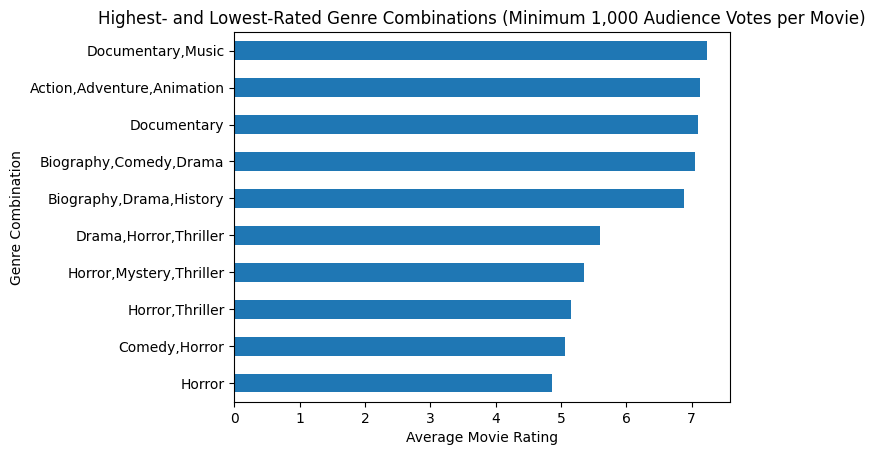

In [21]:
#Let's make a new DataFrame with just the top five and bottom five movies based
#on ratings, which will be used for our plot:
top_5_movies = ratings_by_genre_combination_with_1000_votes_df.head(5)
bottom_5_movies = ratings_by_genre_combination_with_1000_votes_df.tail(5)

plot_df = pd.concat([top_5_movies, bottom_5_movies])

#Now let's make a horizontal bar graph to show this data:
plot_df.plot(kind = "barh", x = "genres", y = "average_rating", legend = False)
plt.xlabel("Average Movie Rating")
plt.ylabel("Genre Combination")
plt.title("Highest- and Lowest-Rated Genre Combinations (Minimum 1,000 Audience Votes per Movie)")
#Make the highest ratings appear on top:
plt.gca().invert_yaxis()
plt.show()

## Answer to Business Question:
Documentary-related films appear to receive the highest audience ratings on IMDb, while horror and thriller films consistently receive the lowest ratings. This suggests that audiences generally like documentary films more than horror films. In the future, if a film production company wishes to focus their efforts on the highest-rated movies, they should spend more money on making documentary and non-fiction movies, and less on horror and thriller movies.

In [22]:
conn4.close()